# Bike Sharing Demand

This notebook contains the **Seoul Bike Dataset** downloaded from Datalab

## Pipeline
Raw Data
   ↓
Feature Engineering
   ↓
Train / Validation Split
   ↓
XGBoost / LightGBM
   ↓
Hyperparameter Tuning
   ↓
Forecast Demand

In [29]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#To ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Load Raw Data

In [30]:
RESULTS_DIR = "data/raw"
df = pd.read_csv(f"{RESULTS_DIR}/SeoulBikeData.csv",encoding='latin1')

## 2. Exploring Data

In [31]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [32]:
target_date = '30/05/2018' 
date_ids = df[df['Date'] == target_date].index
print(date_ids)

Index([4320, 4321, 4322, 4323, 4324, 4325, 4326, 4327, 4328, 4329, 4330, 4331,
       4332, 4333, 4334, 4335, 4336, 4337, 4338, 4339, 4340, 4341, 4342, 4343],
      dtype='int64')


In [58]:
df.loc[4331]

Date                         2018-05-30 00:00:00
Rented Bike Count                            975
Hour                                          11
Temperature(°C)                             22.8
Humidity(%)                                   66
Wind speed (m/s)                             2.7
Visibility (10m)                            1270
Dew point temperature(°C)                   16.1
Solar Radiation (MJ/m2)                     2.76
Rainfall(mm)                                 0.0
Snowfall (cm)                                0.0
Seasons                                   Spring
Holiday                               No Holiday
Functioning Day                              Yes
Name: 4331, dtype: object

In [34]:
df.shape

(8760, 14)

In [35]:
df.dtypes

Date                          object
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                       object
Holiday                       object
Functioning Day               object
dtype: object

In [36]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [38]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8755    False
8756    False
8757    False
8758    False
8759    False
Length: 8760, dtype: bool

In [39]:
df['Date'].value_counts().sort_values()

Date
27/12/2017    24
28/12/2017    24
29/12/2017    24
15/11/2018    24
16/11/2018    24
              ..
17/12/2017    24
16/12/2017    24
15/12/2017    24
14/12/2017    24
30/11/2018    24
Name: count, Length: 365, dtype: int64

In [40]:
df['Seasons'].value_counts().sort_values()

Seasons
Winter    2160
Autumn    2184
Summer    2208
Spring    2208
Name: count, dtype: int64

In [41]:
df['Seasons'].value_counts().sort_values()

Seasons
Winter    2160
Autumn    2184
Summer    2208
Spring    2208
Name: count, dtype: int64

In [42]:
df['Holiday'].value_counts().sort_values()

Holiday
Holiday        432
No Holiday    8328
Name: count, dtype: int64

In [43]:
df['Functioning Day'].value_counts().sort_values()

Functioning Day
No      295
Yes    8465
Name: count, dtype: int64

In [44]:
numeric_df = df.select_dtypes(include='number')


____________________________________________________________________________________________________


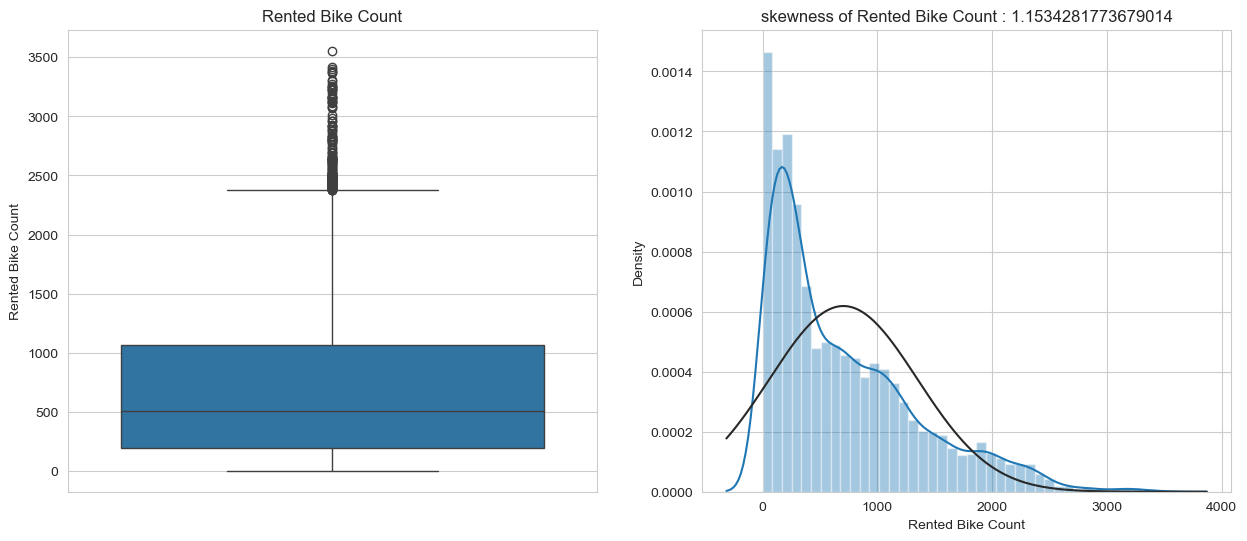

____________________________________________________________________________________________________


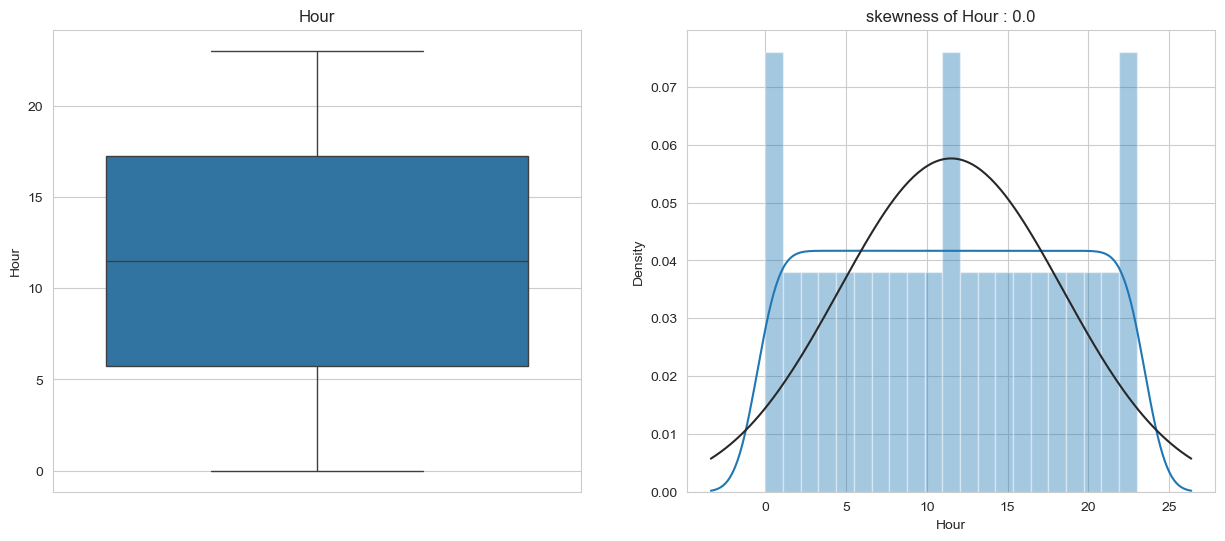

____________________________________________________________________________________________________


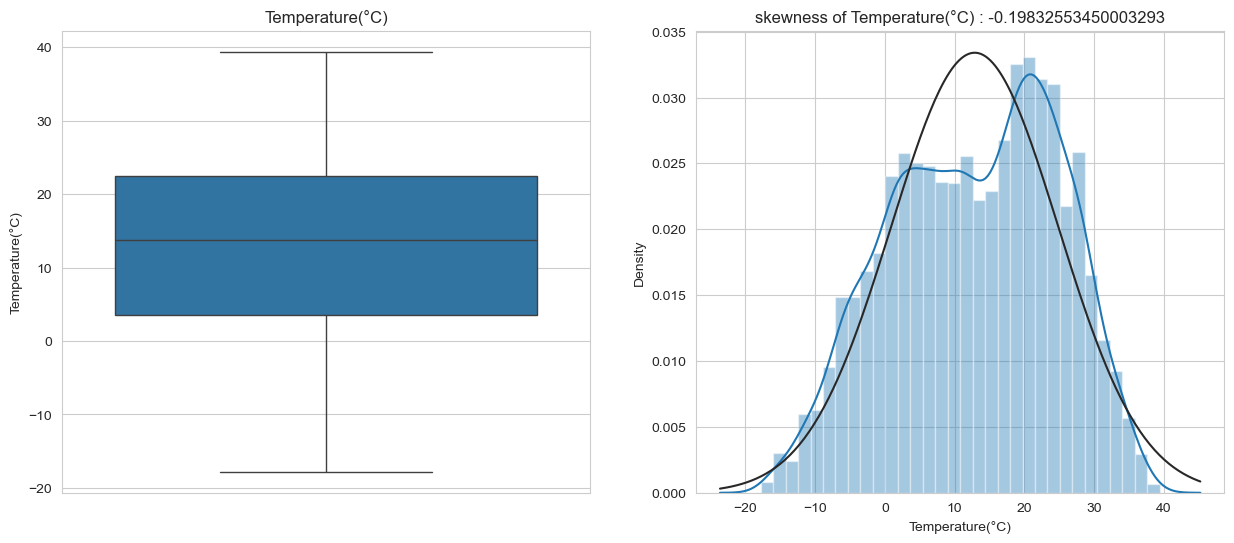

____________________________________________________________________________________________________


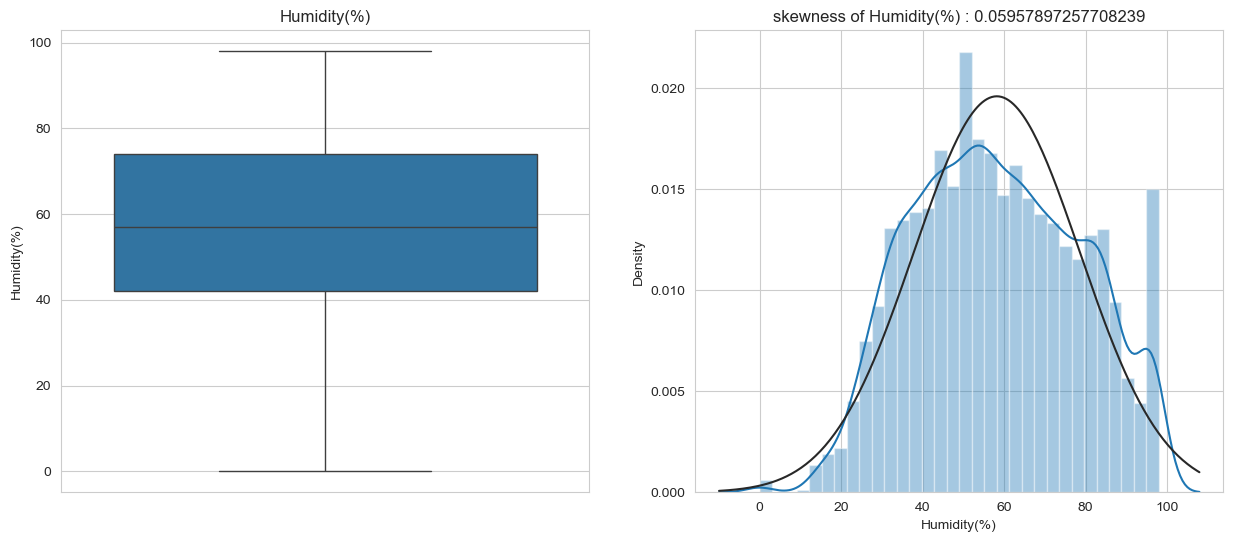

____________________________________________________________________________________________________


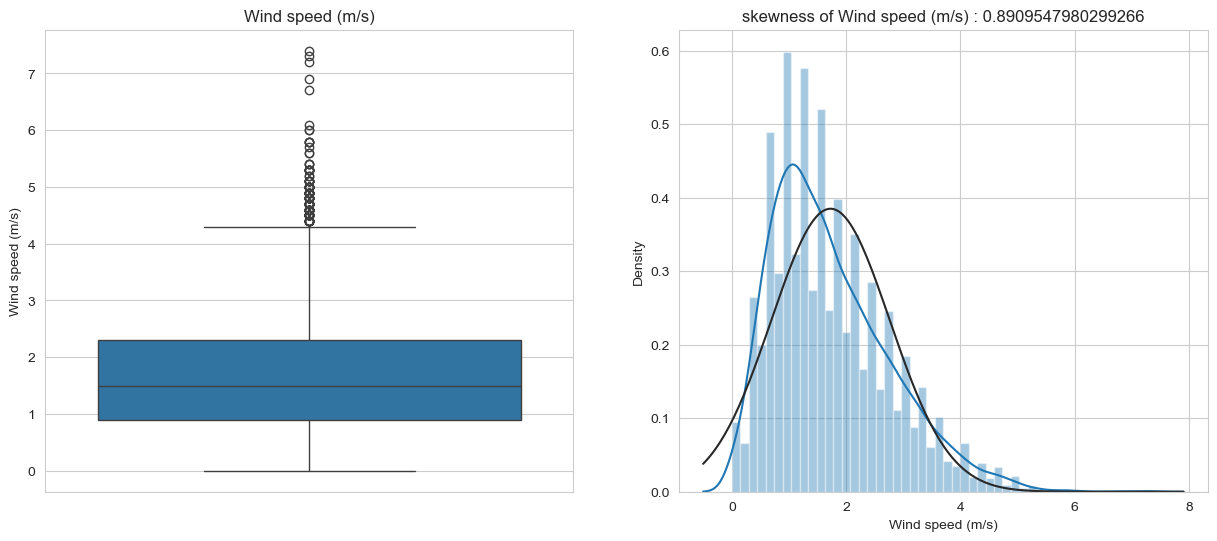

____________________________________________________________________________________________________


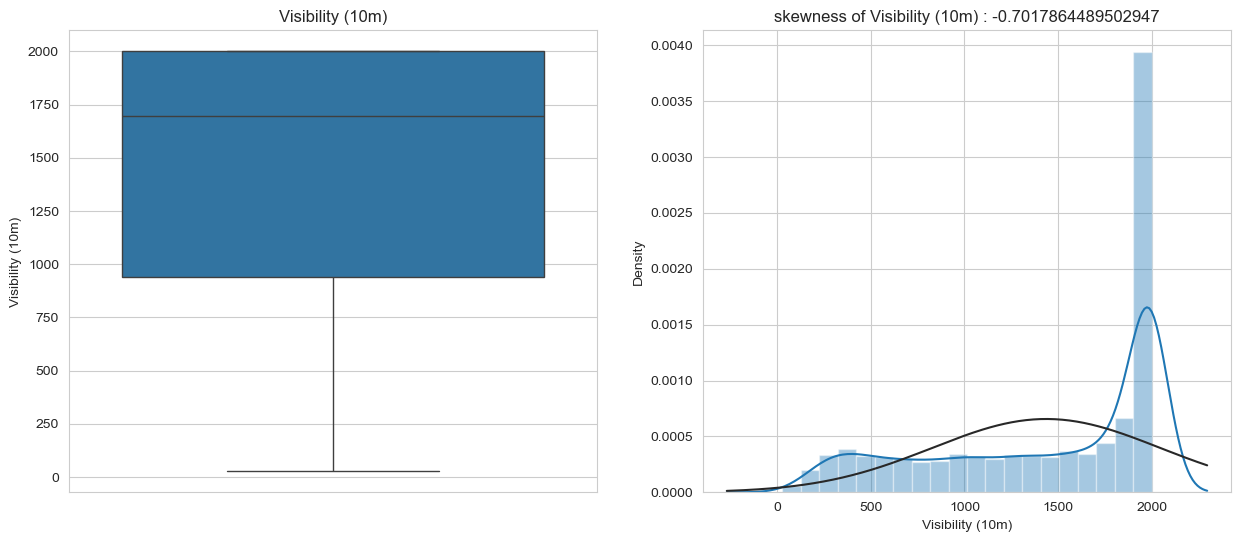

____________________________________________________________________________________________________


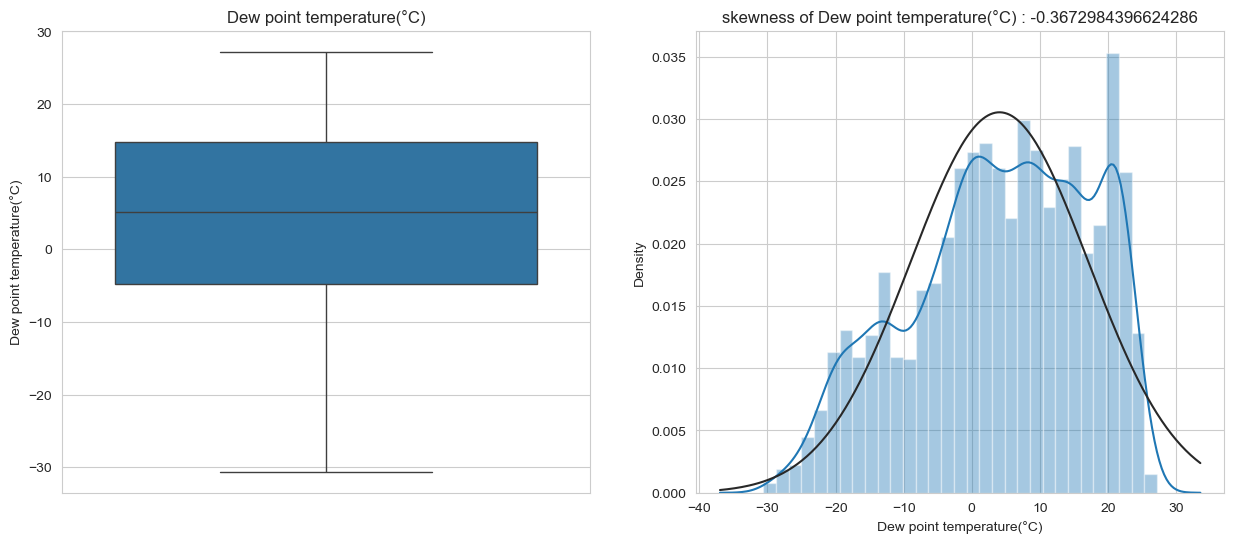

____________________________________________________________________________________________________


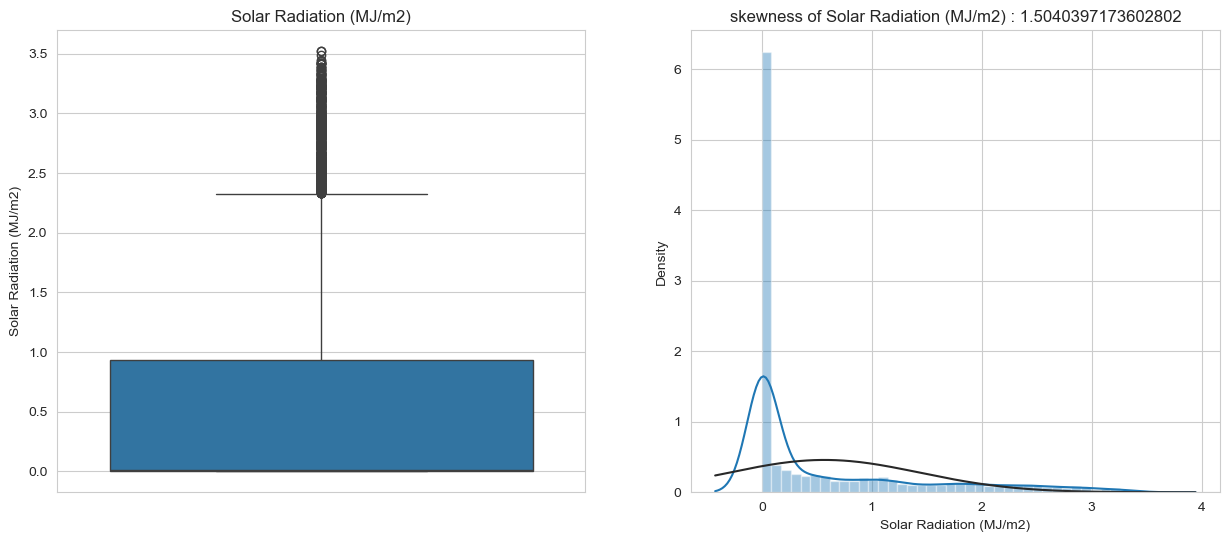

____________________________________________________________________________________________________


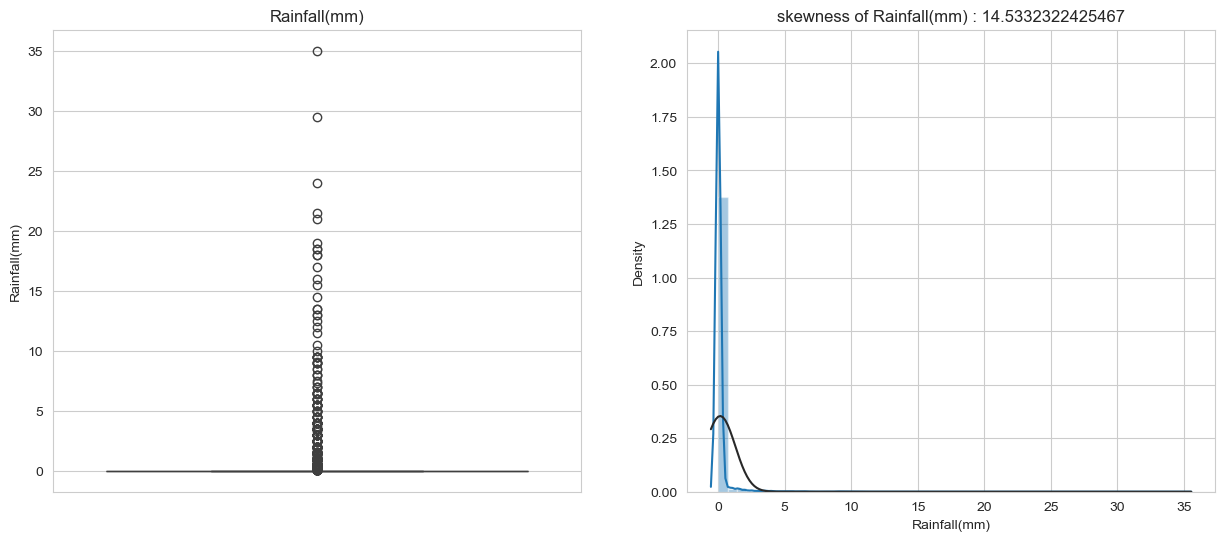

____________________________________________________________________________________________________


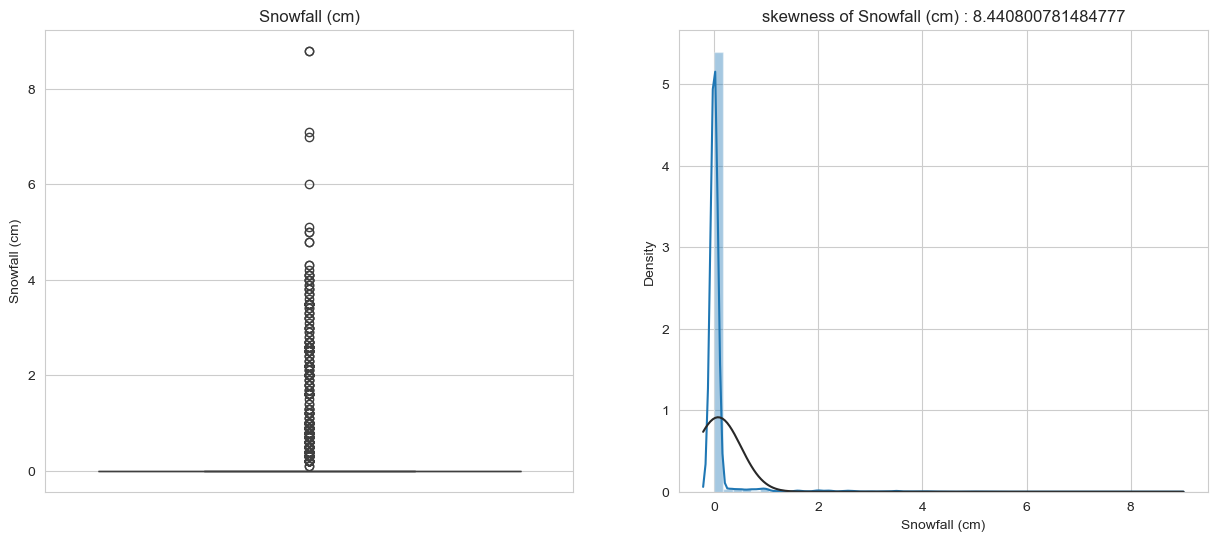

In [45]:
# Checking for outliers in numerical variables using boxplot
from scipy.stats import norm

# Removing "Date" variable from numerical variable
num_var=[var for var in numeric_df.columns if var not in ["Date"]]

# Plotting Box and Distribution plot 
for var in num_var:
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    ax=sns.boxplot(data=df[var])
    ax.set_title(f'{var}')
    ax.set_ylabel(var)

    plt.subplot(1,2,2)
    ax=sns.distplot(df[var], fit=norm)
    ax.set_title(f'skewness of {var} : {df[var].skew()}')
    ax.set_xlabel(var)
    print('__'*50)
    plt.show()

The variables Rented Bike Count, Wind speed (m/s) and 
Rainfall (mm) and Snowfall (cm) have outliers. Rainfall (mm) and Snowfall (cm) have a flat interquartile range; it is best to remove those columns. We will replace them with the Weather_Condition feature.

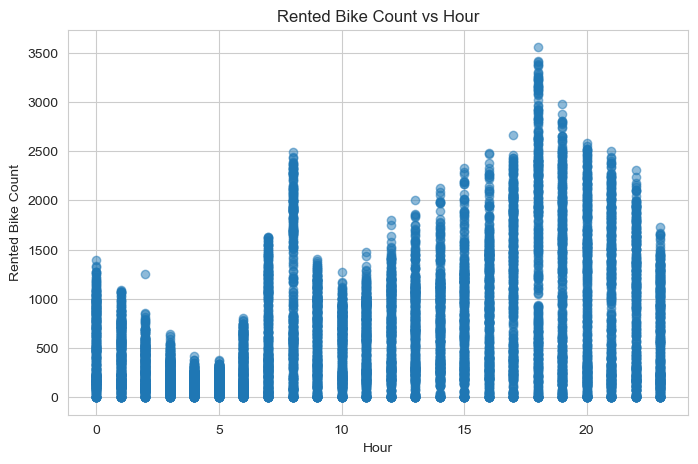

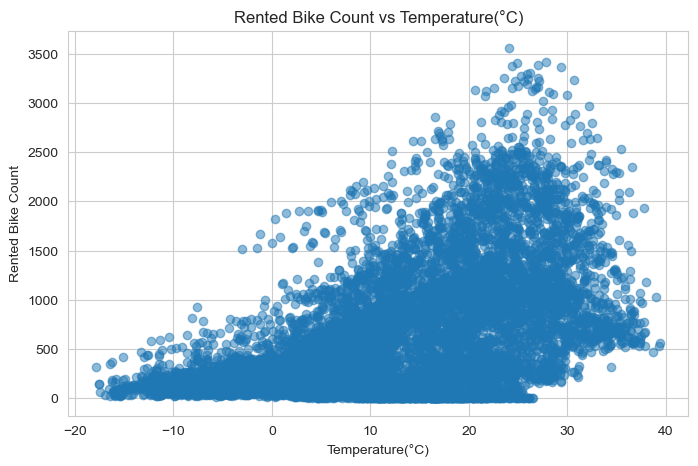

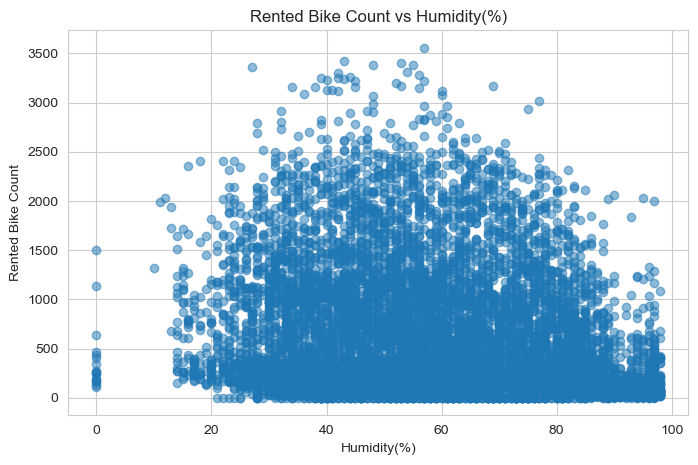

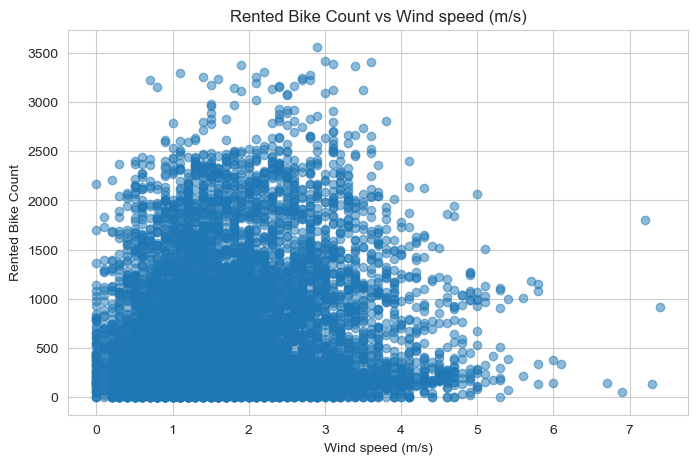

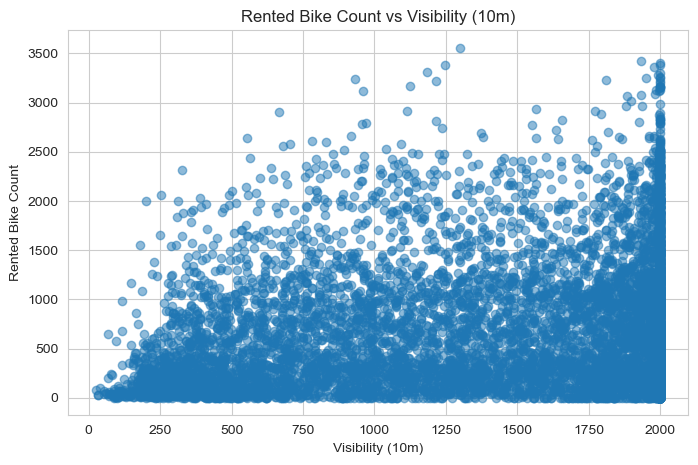

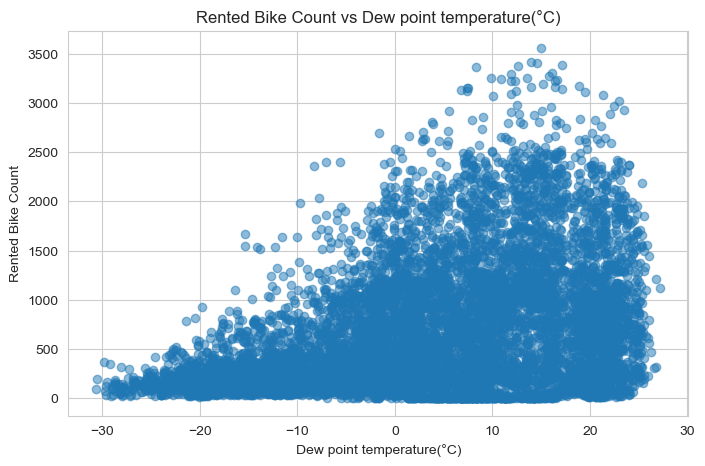

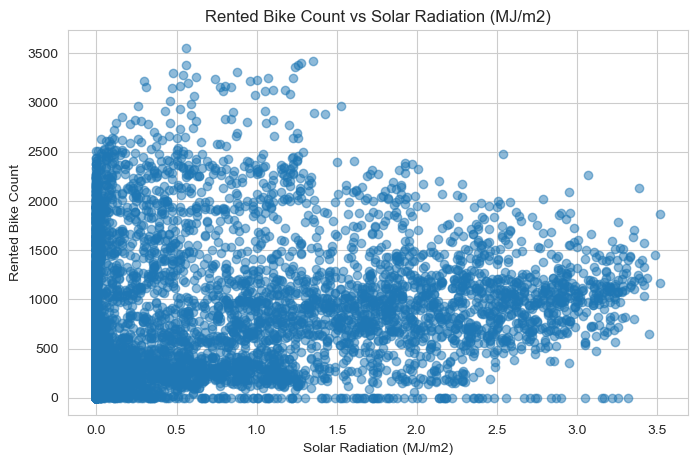

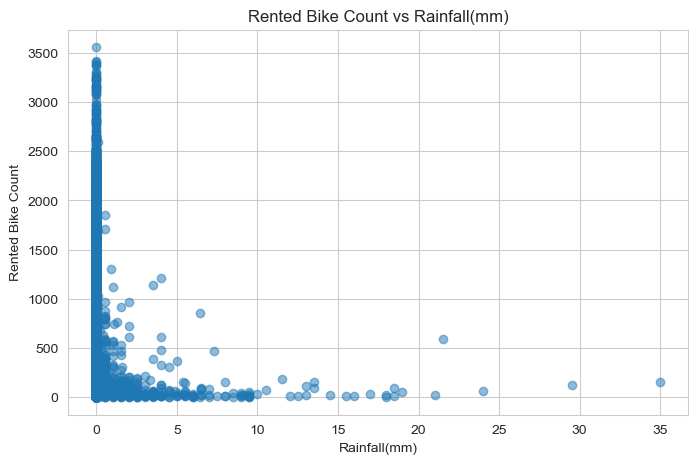

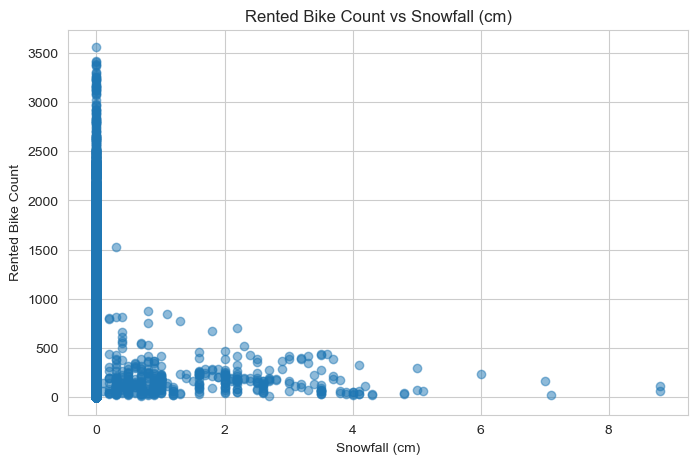

In [46]:
import matplotlib.pyplot as plt

# Clean column names
df.columns = df.columns.str.strip()

# Select numeric columns
numeric_df = df.select_dtypes(include='number')

# Target variable
target = 'Rented Bike Count'

# Create scatter plot for each numeric variable
for column in numeric_df.columns:
    
    # Skip target itself
    if column != target:
        
        plt.figure(figsize=(8,5))
        
        plt.scatter(df[column], df[target], alpha=0.5)
        
        plt.title(f'{target} vs {column}')
        plt.xlabel(column)
        plt.ylabel(target)
        
        plt.show()

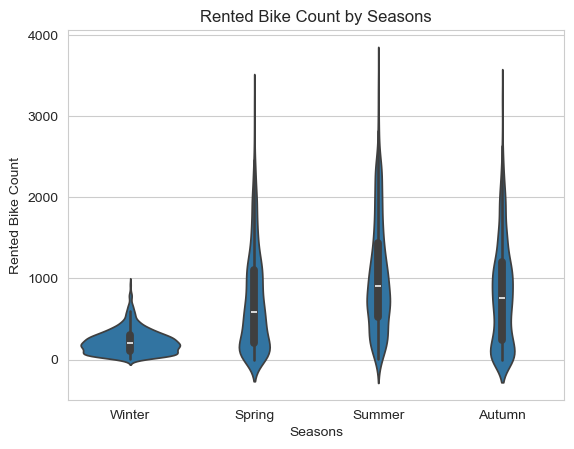

In [47]:
sns.violinplot(
    x='Seasons',
    y='Rented Bike Count',
    data=df
)

plt.title('Rented Bike Count by Seasons')
plt.show()

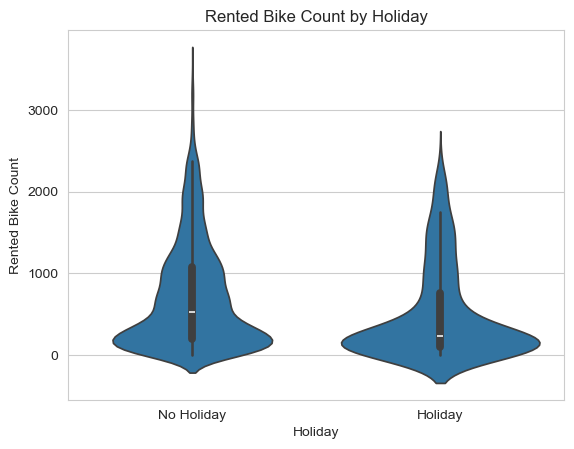

In [48]:
sns.violinplot(
    x='Holiday',
    y='Rented Bike Count',
    data=df
)

plt.title('Rented Bike Count by Holiday')
plt.show()

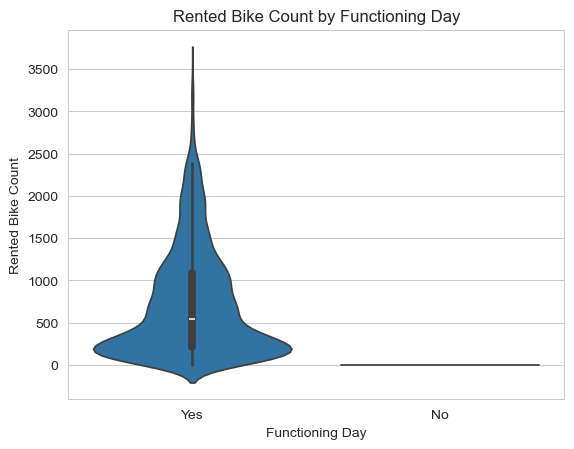

In [49]:
sns.violinplot(
    x='Functioning Day',
    y='Rented Bike Count',
    data=df
)

plt.title('Rented Bike Count by Functioning Day')
plt.show()

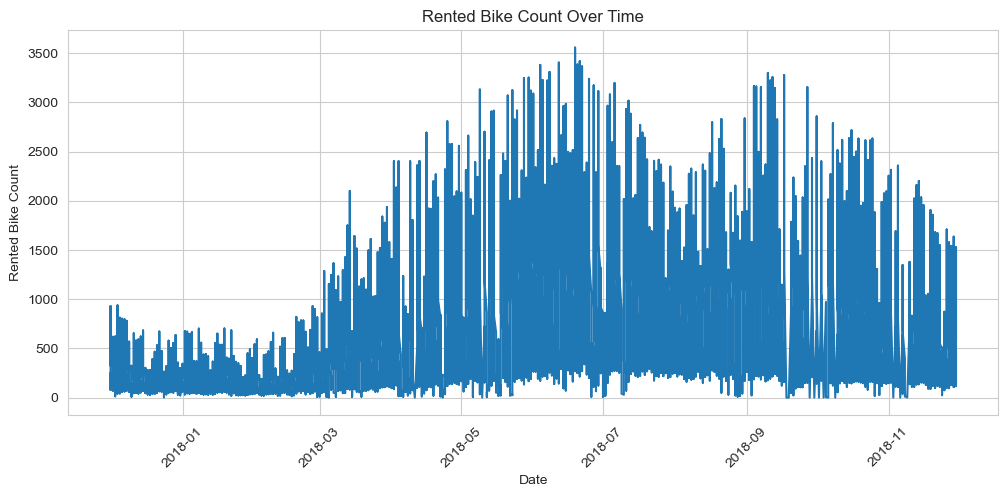

In [50]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Rented Bike Count'])

plt.title('Rented Bike Count Over Time')
plt.xlabel('Date')
plt.ylabel('Rented Bike Count')

plt.xticks(rotation=45)

plt.show()

In [54]:
import plotly.express as px

# 1. Group the data
hourly_demand = df.groupby('Date')['Rented Bike Count'].mean().reset_index()

# 2. Create Interactive Line Chart
fig = px.line(
    hourly_demand,
    x='Date',
    y='Rented Bike Count',
    markers=True,
    title='<b>Rented Bike Count Over Time</b>'
)

# 3. Style
light_green = '#66BB6A'

fig.update_traces(
    line_color=light_green,
    line_width=4,
    marker=dict(
        size=8,
        color=light_green,
        line=dict(width=2, color='white')
    )
)

# 4. Find highest and lowest demand points
max_row = hourly_demand.loc[hourly_demand['Rented Bike Count'].idxmax()]
min_row = hourly_demand.loc[hourly_demand['Rented Bike Count'].idxmin()]

# 5. Add annotations
fig.add_annotation(
    x=max_row['Date'],
    y=max_row['Rented Bike Count'],
    text="<b>Highest Demand</b>",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowcolor=light_green,
    font=dict(color=light_green, size=13),
    ax=0,
    ay=-50
)

fig.add_annotation(
    x=min_row['Date'],
    y=min_row['Rented Bike Count'],
    text="<b>Lowest Demand</b>",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowcolor='red',
    font=dict(color='red', size=13),
    ax=0,
    ay=50
)

# 6. Layout
fig.update_layout(
    width=900,
    height=500,
    title_font=dict(color='black', size=22),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        title='Date',
        showgrid=False
    ),
    yaxis=dict(
        title='Rented Bike Count',
        showgrid=False
    ),
    showlegend=False,
    hovermode='x unified'
)

# 7. Show chart
fig.show()

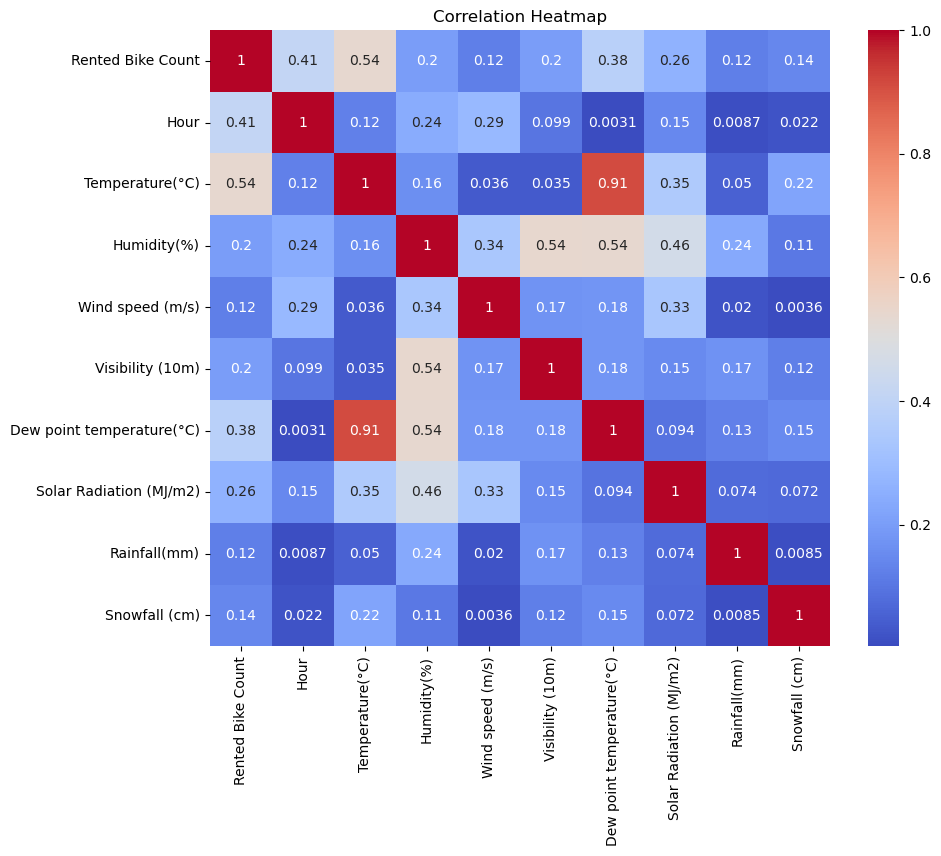

In [ ]:
numeric_df = df.select_dtypes(include='number')

corr = np.abs(numeric_df.corr())

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()